In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from google.colab import files
uploaded=files.upload()

Saving Breast_cancer_data.csv to Breast_cancer_data.csv


In [3]:
df = pd.read_csv('/content/Breast_cancer_data.csv')

In [4]:
df.head()
df.tail()
print("Rows and Columns :", df.shape)

Rows and Columns : (569, 6)


In [5]:
print(df.columns)
df.info()
df.describe()

Index(['mean_radius', 'mean_texture', 'mean_perimeter', 'mean_area',
       'mean_smoothness', 'diagnosis'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   mean_radius      569 non-null    float64
 1   mean_texture     569 non-null    float64
 2   mean_perimeter   569 non-null    float64
 3   mean_area        569 non-null    float64
 4   mean_smoothness  569 non-null    float64
 5   diagnosis        569 non-null    int64  
dtypes: float64(5), int64(1)
memory usage: 26.8 KB


,mean_radius,mean_texture,mean_perimeter,mean_area,mean_smoothness,diagnosis
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.627417
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.483918
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.000000
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.000000
50%,13.370000,18.840000,86.240000,551.100000,0.095870,1.000000
75%,15.780000,21.800000,104.100000,782.700000,0.105300,1.000000
max,28.110000,39.280000,188.500000,2501.000000,0.163400,1.000000


In [6]:
df.isnull().sum()
df = df.drop_duplicates()
df = df.drop_duplicates()

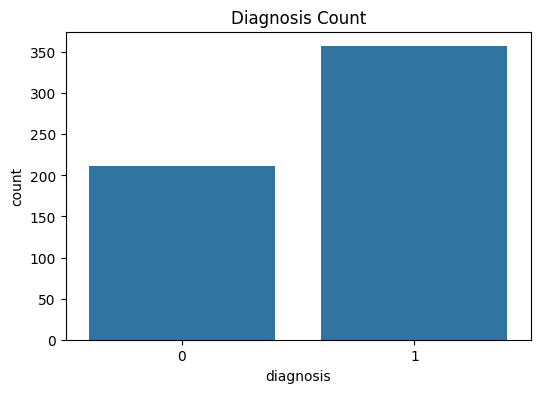

In [7]:
df.dtypes
plt.figure(figsize=(6,4))
sns.countplot(x='diagnosis', data=df)
plt.title("Diagnosis Count")
plt.show()

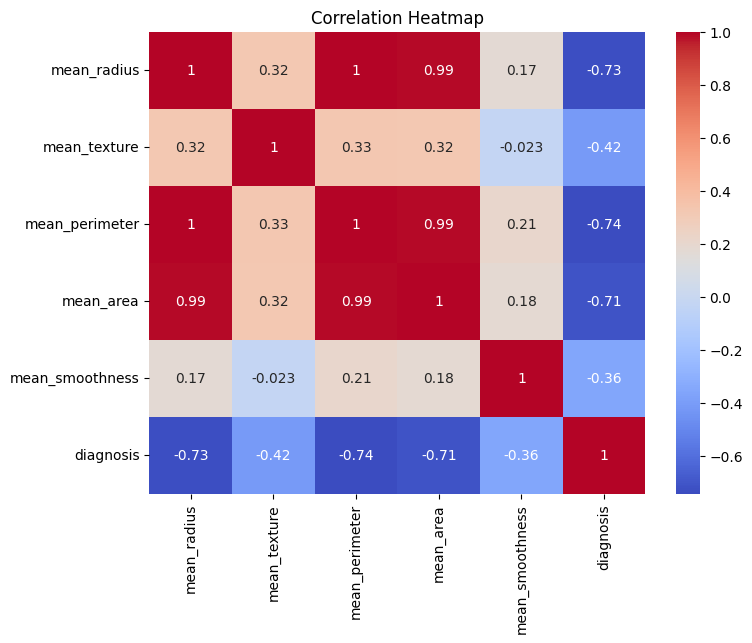

In [8]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

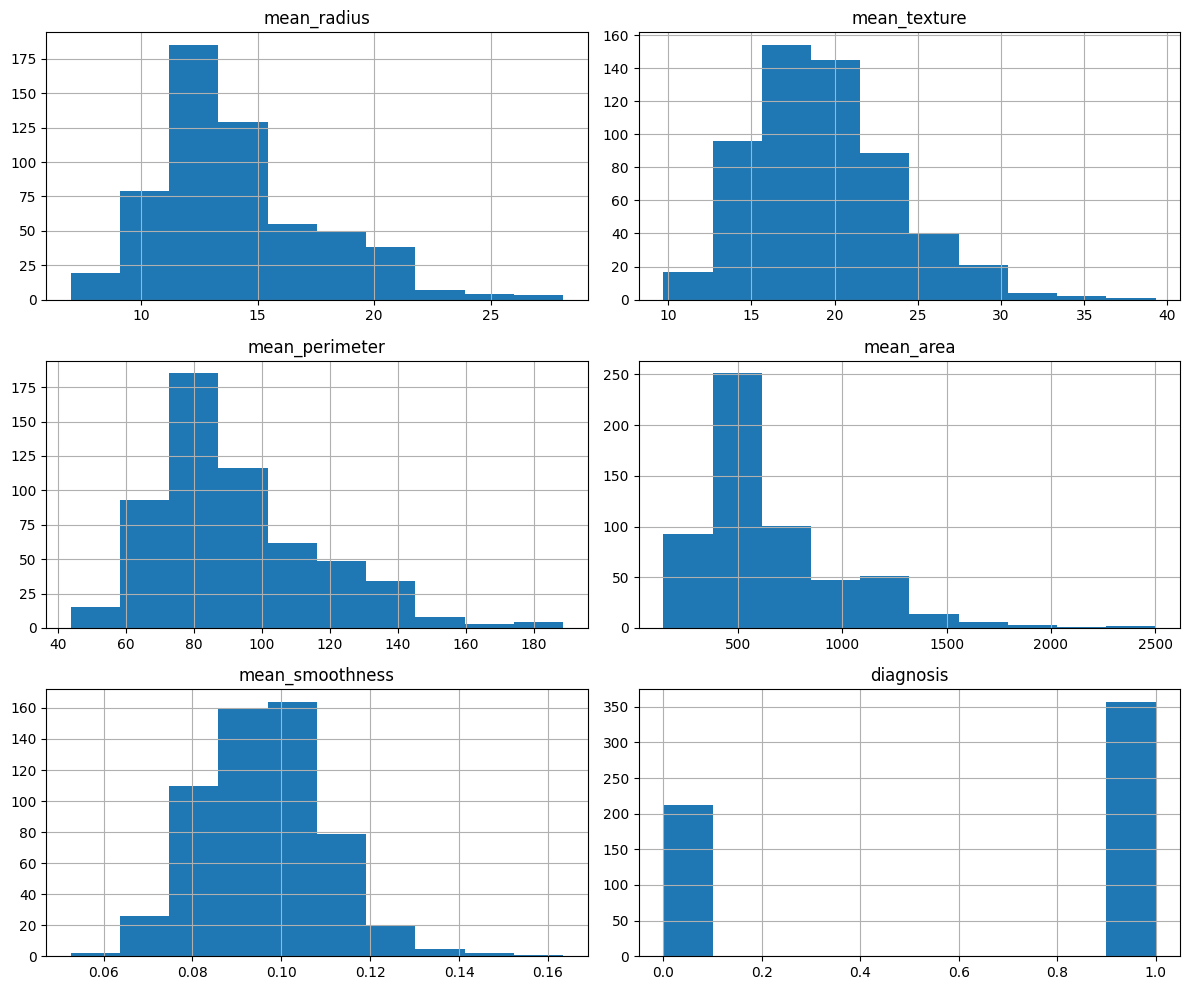

In [9]:
df.hist(figsize=(12,10))
plt.tight_layout()
plt.show()

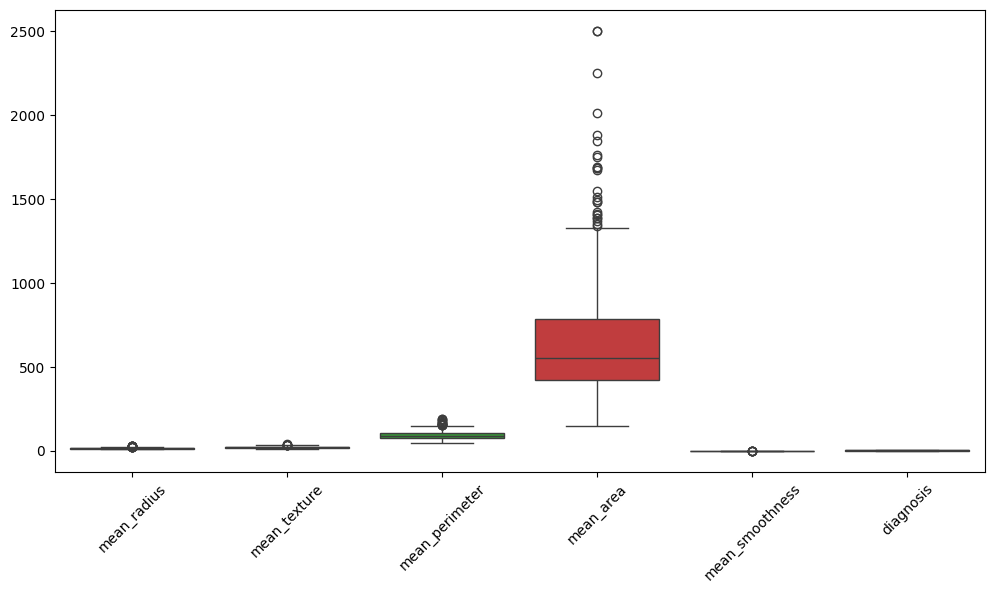

In [10]:
plt.figure(figsize=(12,6))
sns.boxplot(data=df)
plt.xticks(rotation=45)
plt.show()

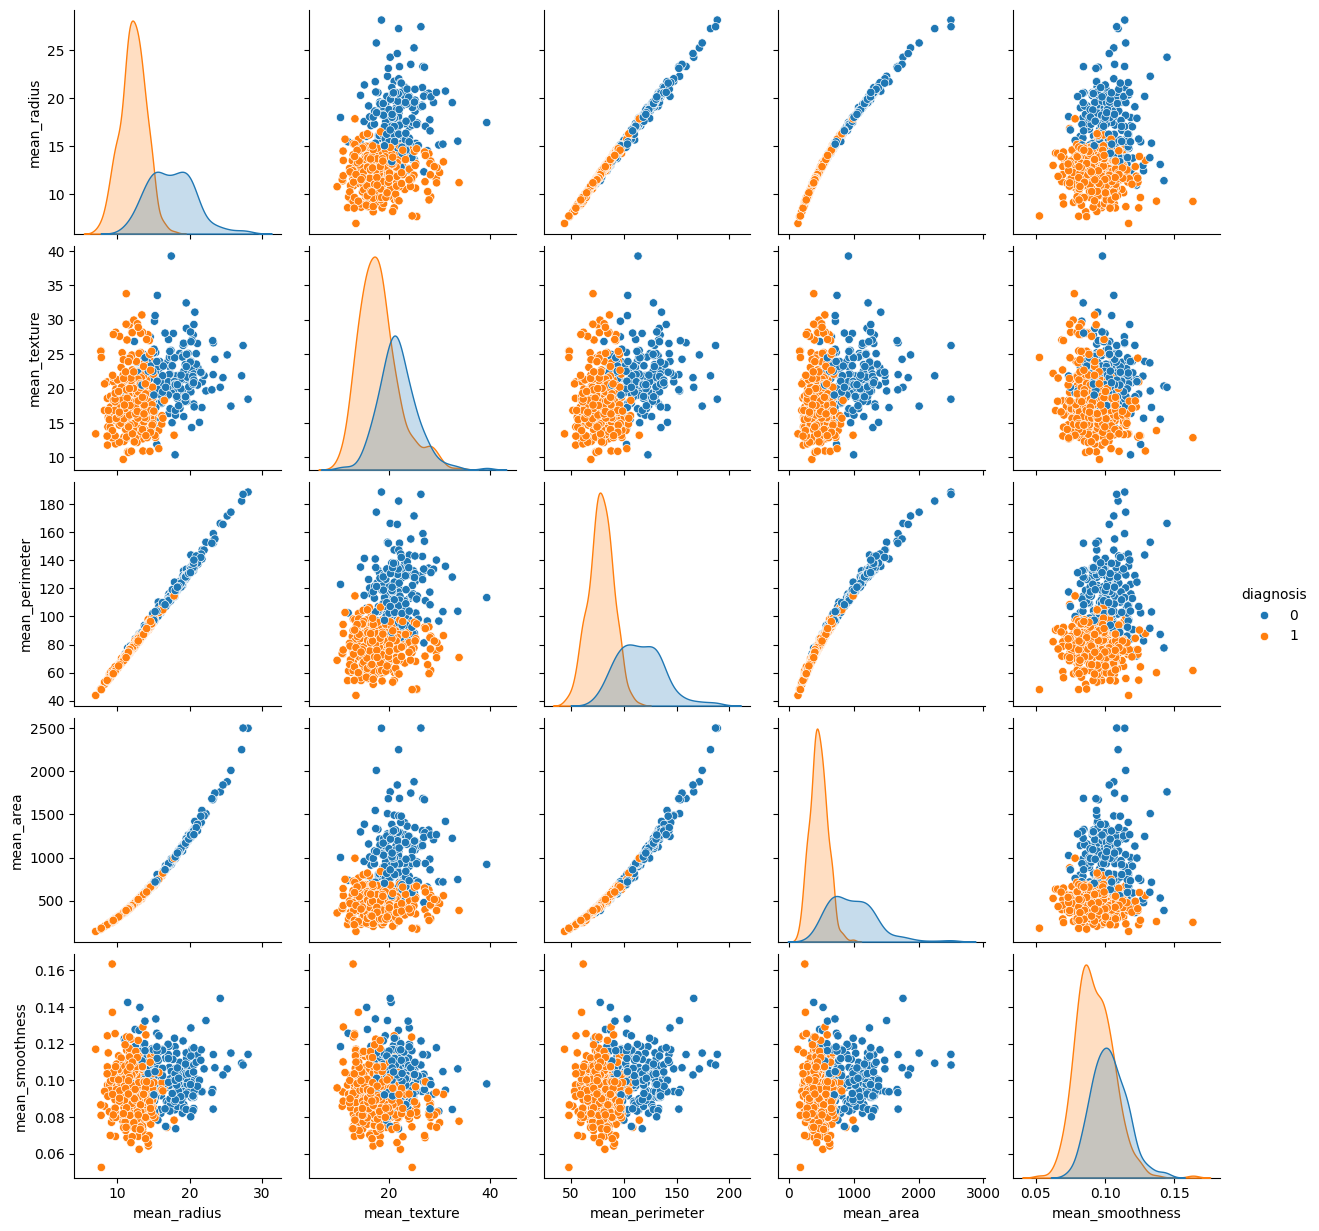

In [12]:
sns.pairplot(df, hue="diagnosis")
plt.show()

In [13]:
# Features
X = df.drop('diagnosis', axis=1)

# Target
y = df['diagnosis']

In [14]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [15]:
from sklearn.decomposition import PCA

# Reduce to 2 Principal Components
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

In [16]:
print("Explained Variance Ratio:")
print(pca.explained_variance_ratio_)

Explained Variance Ratio:
[0.63446825 0.2042183 ]


In [17]:
pca_df = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])

pca_df['Diagnosis'] = y

pca_df.head()

,PC1,PC2,Diagnosis
0,1.562077,2.464472,0
1,2.801064,-0.466274,0
2,2.848768,0.593637,0
3,-0.658477,2.624944,0
4,2.718517,0.897870,0


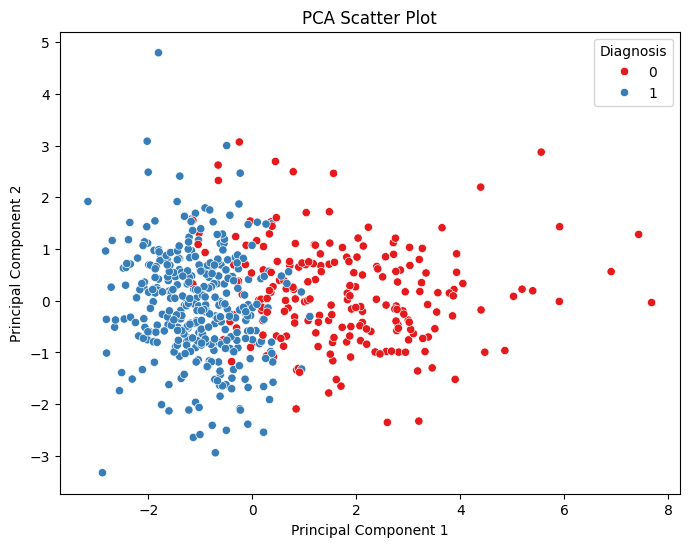

In [18]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x='PC1',
    y='PC2',
    hue='Diagnosis',
    data=pca_df,
    palette='Set1'
)

plt.title("PCA Scatter Plot")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()

In [19]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_pca,
    y,
    test_size=0.2,
    random_state=42
)

In [20]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()

model.fit(X_train, y_train)

LogisticRegression()

In [21]:
y_pred = model.predict(X_test)

print(y_pred)

[1 0 0 1 1 0 0 0 1 1 1 0 1 0 1 0 1 1 1 0 1 1 0 1 1 0 1 1 1 0 1 1 1 1 1 1 0
 1 0 1 1 0 1 1 1 1 1 1 1 1 0 0 1 0 1 1 1 0 1 1 1 0 0 1 1 1 0 0 1 1 0 0 1 0
 1 1 1 1 1 1 0 1 1 0 0 0 1 0 1 1 1 1 0 1 1 1 0 0 1 0 0 1 0 0 1 1 1 0 1 1 0
 1 1 0]


In [22]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.9298245614035088


In [23]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[38  5]
 [ 3 68]]


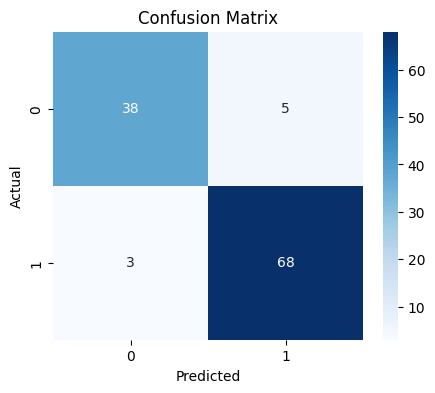

In [24]:
plt.figure(figsize=(5,4))

sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [25]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.93      0.88      0.90        43
           1       0.93      0.96      0.94        71

    accuracy                           0.93       114
   macro avg       0.93      0.92      0.92       114
weighted avg       0.93      0.93      0.93       114



In [26]:
result = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_pred
})

result.head(20)

,Actual,Predicted
204,1,1
70,0,0
131,0,0
431,1,1
540,1,1
567,0,0
369,0,0
29,0,0
81,1,1
477,1,1


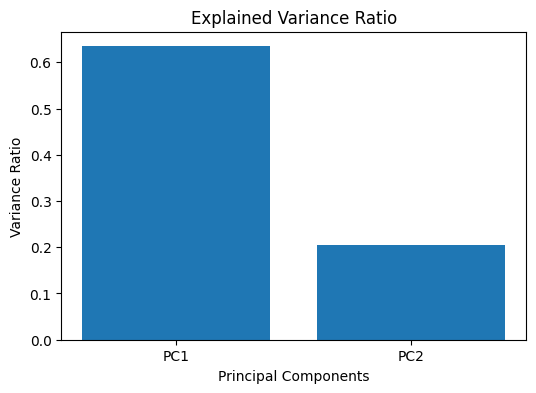

In [27]:
variance = pca.explained_variance_ratio_

plt.figure(figsize=(6,4))

plt.bar(['PC1', 'PC2'], variance)

plt.title("Explained Variance Ratio")
plt.xlabel("Principal Components")
plt.ylabel("Variance Ratio")

plt.show()